# Round 2 NLP Analysis — DATA VORTEX A'26
## "Rebuilding the Social Engine" — Sentiment Classification Pipeline

**Full pipeline walkthrough**: data audit → preprocessing → EDA → baselines → model experiments → final model → evaluation → error analysis → inference demo.

All heavy computation is implemented in `src/` modules; this notebook imports those modules and presents results rather than re-implementing logic. Re-running this notebook top-to-bottom in a clean kernel is sufficient to reproduce all outputs.

---
**Model**: `char(3,5) + LinearSVC C=1.0`  
**Test macro-F1**: **60.93%**  
**Random seed**: 42  
**Python**: 3.10.11  |  **scikit-learn**: 1.4.2  |  **pandas**: 2.2.2

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────────
import sys, os
from pathlib import Path

# Ensure we're at the project root so all relative paths resolve correctly
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))

print(f'Project root: {ROOT}')
print(f'Python: {sys.version.split()[0]}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sklearn
import pickle, json, warnings
warnings.filterwarnings('ignore')

print(f'pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__} | sklearn {sklearn.__version__}')

Project root: C:\Users\dhrit\Downloads\datavortex\Round2
Python: 3.10.11


pandas 2.2.2 | numpy 1.26.4 | matplotlib 3.8.2 | sklearn 1.4.2


---
## 1. Data Audit Highlights (Phase 1)

Full audit: `reports/audit_report.md`

In [2]:
# Load raw data and reproduce key audit facts
raw_df = pd.read_csv('data/Labeled_Social_NLP_Training_Data.csv', dtype=str, keep_default_na=False)
print(f'Raw dataset: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns')
print(f'Columns: {raw_df.columns.tolist()}')
print(f'\nSentiment distribution:')
print(raw_df['sentiment_label'].value_counts().to_string())
print(f'\nDuplicate post_text rows: {raw_df.duplicated(subset="post_text", keep=False).sum():,}')
print(f'Zero null values: {raw_df.isnull().sum().sum()}')

Raw dataset: 9,000 rows × 4 columns
Columns: ['text_id', 'post_text', 'sentiment_label', 'topic_category']

Sentiment distribution:
sentiment_label
Negative    3000
Positive    3000
Neutral     3000

Duplicate post_text rows: 2,087
Zero null values: 0


In [3]:
# Text quality issues
import re
unicode_esc = raw_df['post_text'].str.contains(r'\\u[0-9A-Fa-f]{4}', regex=True)
html_ent    = raw_df['post_text'].str.contains(r'&(?:amp|quot|#39|lt|gt);', regex=True, case=False)
at_mention  = raw_df['post_text'].str.contains(r'@[A-Za-z0-9_]+', regex=True)
print(f'Rows with \\uXXXX unicode escapes : {unicode_esc.sum():,} ({unicode_esc.mean()*100:.1f}%)')
print(f'Rows with HTML entities          : {html_ent.sum():,} ({html_ent.mean()*100:.1f}%)')
print(f'Rows with @mentions              : {at_mention.sum():,} ({at_mention.mean()*100:.1f}%)')

Rows with \uXXXX unicode escapes : 1,092 (12.1%)
Rows with HTML entities          : 360 (4.0%)
Rows with @mentions              : 2,659 (29.5%)


---
## 2. Preprocessing Pipeline (Phase 2)

Full log: `reports/cleaning_log.md`

In [4]:
from utils import clean_text

# Demonstrate cleaning on the 4 types of raw-data issues
examples = [
    (r"It\u2019s D Wade\u2019s b day... I feel bad he\u2019ll lose",
     "Unicode escape decode"),
    ("@user Hi! KAI stole my heart &amp; it's not changing",
     "HTML entity + @mention"),
    ("Check https://example.com for details #trending",
     "URL replacement"),
    (r"Tune into @DhritTV tonight\u2019s finale! &amp; Check https://t.co/abc",
     "All issues combined"),
]

print(f'{"Type":<30} {"Raw (truncated)":<50} {"Clean (truncated)"}')
print('-' * 110)
for raw, label in examples:
    cleaned = clean_text(raw)
    print(f'{label:<30} {raw[:48]:<50} {cleaned[:55]}')

Type                           Raw (truncated)                                    Clean (truncated)
--------------------------------------------------------------------------------------------------------------
Unicode escape decode          It\u2019s D Wade\u2019s b day... I feel bad he\u   It’s D Wade’s b day... I feel bad he’ll lose
HTML entity + @mention         @user Hi! KAI stole my heart &amp; it's not chan   @user Hi! KAI stole my heart & it's not changing
URL replacement                Check https://example.com for details #trending    Check <url> for details #trending
All issues combined            Tune into @DhritTV tonight\u2019s finale! &amp;    Tune into @user tonight’s finale! & Check <url>


In [5]:
# Split sizes and class balance
split_info = {
    'train': pd.read_csv('data/processed/train.csv', dtype=str, keep_default_na=False),
    'val':   pd.read_csv('data/processed/val.csv',   dtype=str, keep_default_na=False),
    'test':  pd.read_csv('data/processed/test.csv',  dtype=str, keep_default_na=False),
}
for split, df in split_info.items():
    counts = df['sentiment_label'].value_counts()
    print(f'{split:6s}: {len(df):5d} rows | Neg={counts.get("Negative",0)} Neu={counts.get("Neutral",0)} Pos={counts.get("Positive",0)}')
print(f'\nGroup-aware split: no text_clean shared across splits (verified in Phase 2)')

# Verify no text leakage
train_texts = set(split_info['train']['text_clean'])
val_texts   = set(split_info['val']['text_clean'])
test_texts  = set(split_info['test']['text_clean'])
print(f'Train∩Val overlap: {len(train_texts & val_texts)} (must be 0)')
print(f'Train∩Test overlap: {len(train_texts & test_texts)} (must be 0)')
print(f'Val∩Test overlap: {len(val_texts & test_texts)} (must be 0)')

train :  6279 rows | Neg=2095 Neu=2099 Pos=2085
val   :  1375 rows | Neg=466 Neu=448 Pos=461
test  :  1346 rows | Neg=439 Neu=453 Pos=454

Group-aware split: no text_clean shared across splits (verified in Phase 2)
Train∩Val overlap: 0 (must be 0)
Train∩Test overlap: 0 (must be 0)
Val∩Test overlap: 0 (must be 0)


---
## 3. Exploratory Data Analysis (Phase 3)

Full report: `reports/eda_report.md`. Key figures reproduced below.

Figure 1: Sentiment class distribution


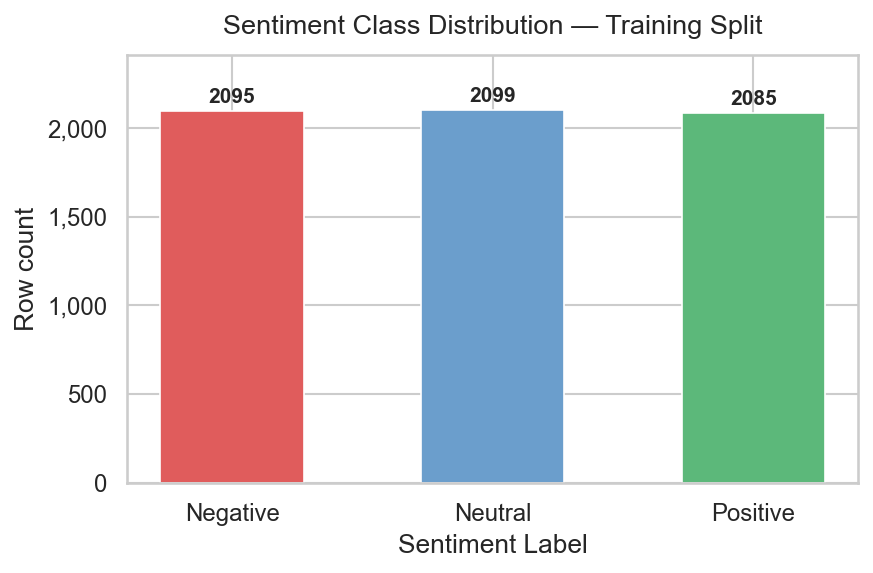

In [6]:
# Display EDA figures produced by Phase 3
from IPython.display import Image, display
fig_dir = Path('reports/figures')

print('Figure 1: Sentiment class distribution')
display(Image(filename=str(fig_dir / 'fig1_sentiment_class_dist.png'), width=480))

Figure 2: Word count distribution by sentiment class


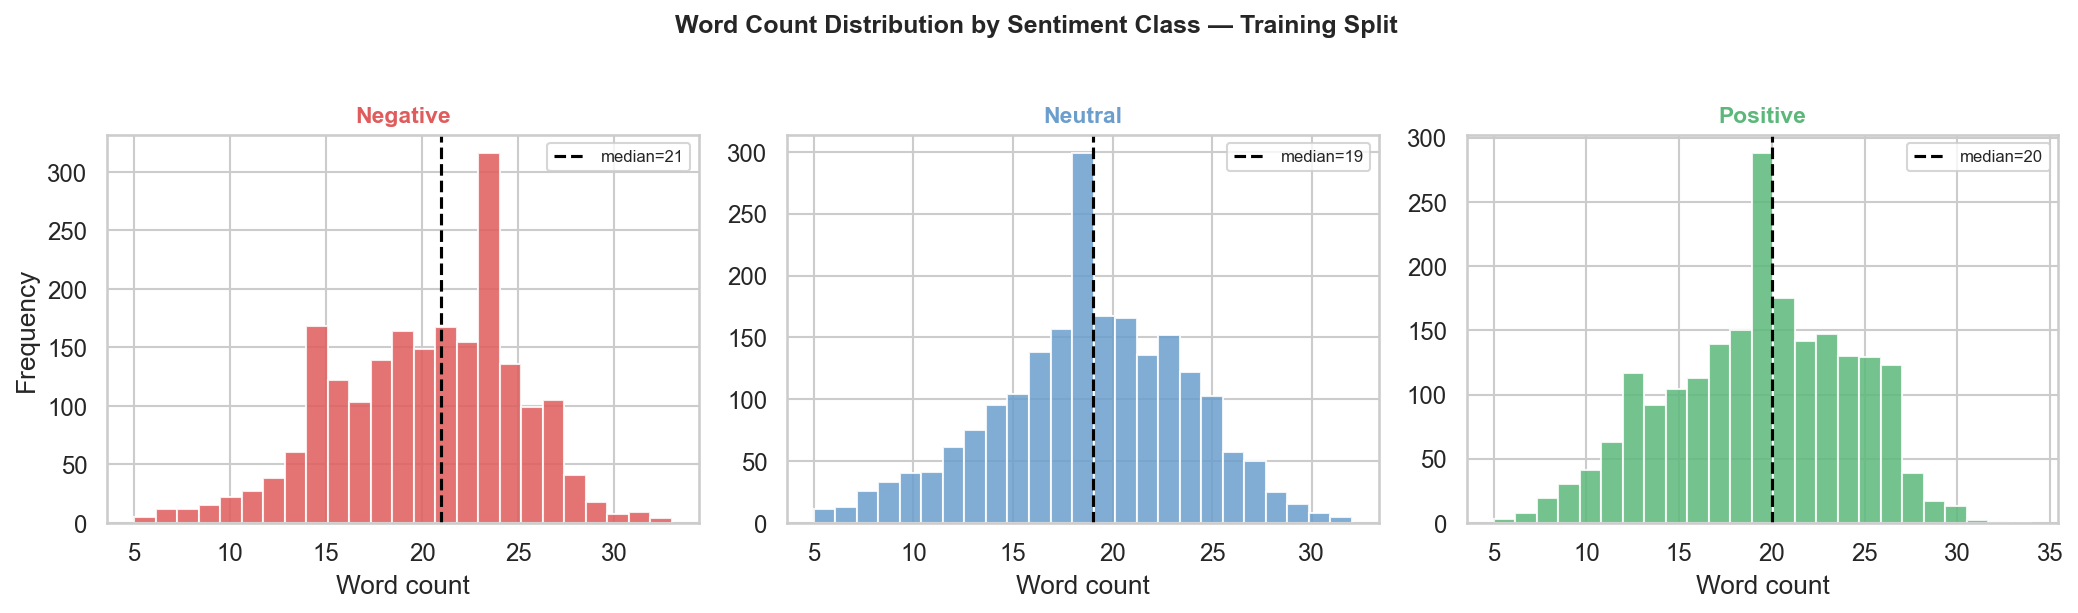

In [7]:
print('Figure 2: Word count distribution by sentiment class')
display(Image(filename=str(fig_dir / 'fig2_wordcount_by_class.png'), width=600))

Figure 3: Top-20 unigrams by sentiment class


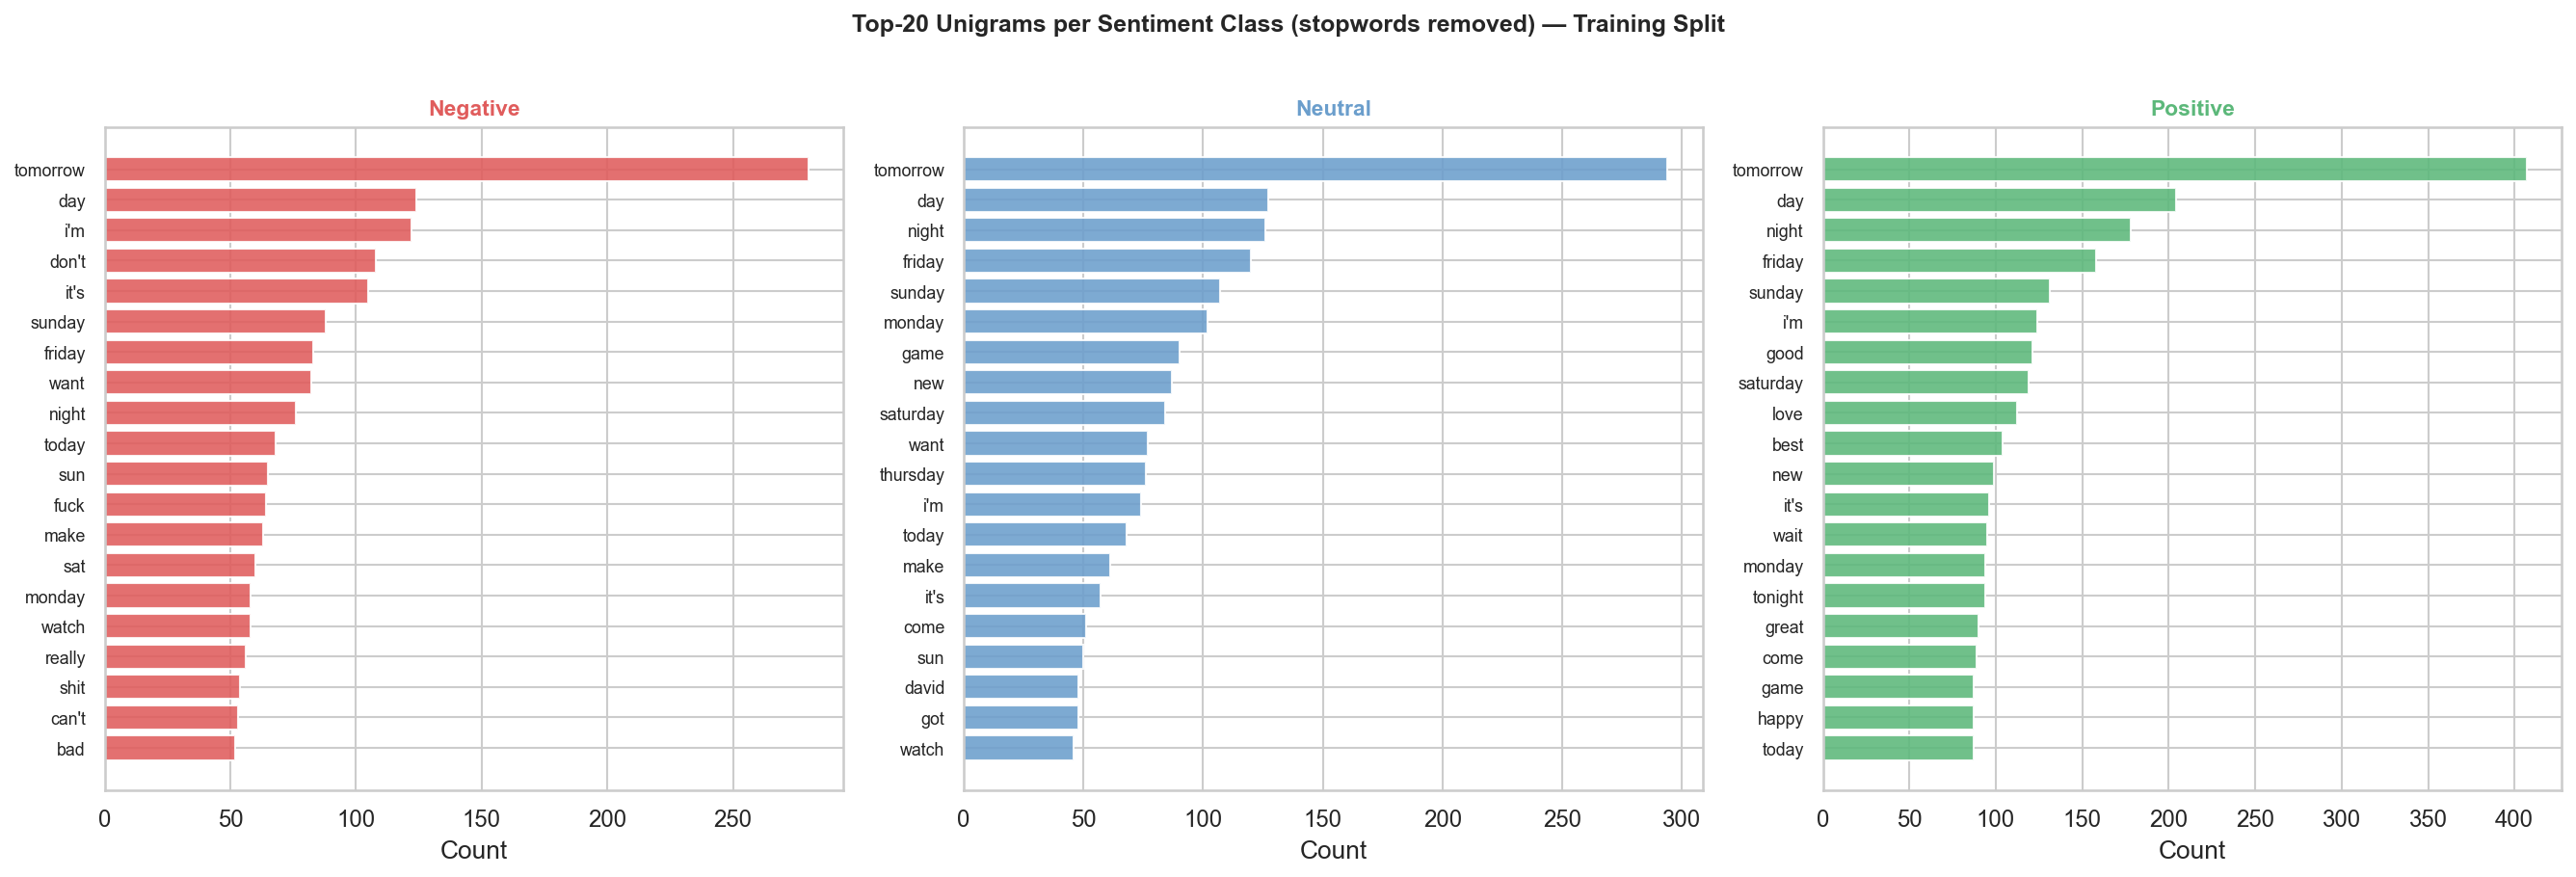

In [8]:
print('Figure 3: Top-20 unigrams by sentiment class')
display(Image(filename=str(fig_dir / 'fig3_top20_unigrams_by_class.png'), width=700))

---
## 4. Baseline Models (Phase 4)

Full results: `reports/baseline_results.md` and `reports/baseline_results.csv`

In [9]:
baseline_df = pd.read_csv('reports/baseline_results.csv')
display_cols = ['model', 'accuracy', 'macro_F1', 'F1_Negative', 'F1_Neutral', 'F1_Positive', 'train_secs']
baseline_df[display_cols].style \
    .format({'accuracy': '{:.4f}', 'macro_F1': '{:.4f}',
             'F1_Negative': '{:.4f}', 'F1_Neutral': '{:.4f}', 'F1_Positive': '{:.4f}'}) \
    .background_gradient(subset=['macro_F1'], cmap='RdYlGn') \
    .set_caption('Phase 4 Baseline Results (evaluated on val.csv)')

,model,accuracy,macro_F1,F1_Negative,F1_Neutral,F1_Positive,train_secs
0,"TF-IDF char(3,5) + LR",0.5891,0.5881,0.6296,0.4950,0.6398,6.110000
1,"TF-IDF(1,2) + SVM",0.5818,0.5818,0.6329,0.5060,0.6065,0.880000
2,"TF-IDF(1,2) + LR",0.5731,0.5725,0.6092,0.5022,0.6060,1.370000
3,"TF-IDF(1,2) + MNB",0.5738,0.5692,0.6166,0.4723,0.6187,0.790000
4,Stratified-random,0.3556,0.3557,0.3518,0.3620,0.3533,0.010000
5,Majority-class,0.3258,0.1638,0.0000,0.4915,0.0000,0.000000


In [10]:
incumbent = baseline_df.loc[baseline_df['macro_F1'].idxmax()]
print(f'Phase 4 Incumbent: {incumbent["model"]}')
print(f'  Val accuracy: {incumbent["accuracy"]*100:.2f}%')
print(f'  Val macro-F1: {incumbent["macro_F1"]*100:.2f}%')
print(f'  Train time  : {incumbent["train_secs"]}s')

Phase 4 Incumbent: TF-IDF char(3,5) + LR
  Val accuracy: 58.91%
  Val macro-F1: 58.81%
  Train time  : 6.11s


---
## 5. Phase 5 Experiments — Fast Path (no GridSearchCV)

Full report: `reports/model_selection.md` and `reports/experiment_log.csv`

In [11]:
exp_df = pd.read_csv('reports/experiment_log.csv')
display_cols = ['run_id', 'config', 'val_accuracy', 'val_macro_f1', 'F1_Negative', 'F1_Neutral', 'F1_Positive', 'train_time']
exp_df.sort_values('val_macro_f1', ascending=False)[display_cols].style \
    .format({'val_accuracy': '{:.4f}', 'val_macro_f1': '{:.4f}',
             'F1_Negative': '{:.4f}', 'F1_Neutral': '{:.4f}', 'F1_Positive': '{:.4f}'}) \
    .background_gradient(subset=['val_macro_f1'], cmap='RdYlGn') \
    .set_caption('Phase 5 Experiment Results — Fast Path (val.csv)')


,run_id,config,val_accuracy,val_macro_f1,F1_Negative,F1_Neutral,F1_Positive,train_time
0,Exp-D,"char(3,5)+LinearSVC C=1.0",0.6015,0.6011,0.6423,0.5330,0.6279,3.730000
1,Exp-B,"char(3,5)+LR C=5.0",0.5971,0.5974,0.6265,0.5335,0.6323,6.080000
2,Exp-C,"FeatureUnion(char(3,5)+word(1,2))+LR C=1.0",0.5942,0.5941,0.6289,0.5186,0.6347,6.060000
3,Exp-E,"char(3,5)+LR C=1.0 class_weight=balanced",0.5891,0.5881,0.6289,0.4955,0.6398,4.950000
4,Exp-A,"char(3,5)+LR C=0.5",0.5884,0.5874,0.6351,0.4994,0.6275,2.370000


In [12]:
INCUMBENT_F1 = 0.5881
best_exp = exp_df.loc[exp_df['val_macro_f1'].idxmax()]
print(f'Phase 4 incumbent val macro-F1: {INCUMBENT_F1*100:.2f}%')
print(f'Winner: {best_exp["run_id"]} — {best_exp["config"]}')
print(f'  Val macro-F1: {best_exp["val_macro_f1"]*100:.2f}%')
print(f'  Improvement : +{(best_exp["val_macro_f1"]-INCUMBENT_F1)*100:.2f} pp')
print(f'  Train time  : {best_exp["train_time"]}s')

Phase 4 incumbent val macro-F1: 58.81%
Winner: Exp-D — char(3,5)+LinearSVC C=1.0
  Val macro-F1: 60.11%
  Improvement : +1.30 pp
  Train time  : 3.73s


---
## 6. Final Model Evaluation on Test Split (Phase 6)

**One-shot rule**: `test.csv` was opened exactly once (Phase 6). Results are read from the generated report — the model is not re-evaluated here.

Full report: `reports/evaluation_report.md`

In [13]:
# Display pre-computed results — do NOT call model.predict(test) again
results = {
    'Test Accuracy':     '60.92%',
    'Test Macro-F1':     '60.93%',
    'Test Macro-P':      '60.94%',
    'Test Macro-R':      '60.99%',
    'F1 — Negative':     '65.48%',
    'F1 — Neutral':      '56.61%',
    'F1 — Positive':     '60.70%',
    'Val/Test delta':    '+0.82 pp',
}
for k, v in results.items():
    print(f'  {k:<22}: {v}')
print()
print('Source: reports/evaluation_report.md (generated 2026-09-19T01:05:10Z)')

  Test Accuracy         : 60.92%
  Test Macro-F1         : 60.93%
  Test Macro-P          : 60.94%
  Test Macro-R          : 60.99%
  F1 — Negative         : 65.48%
  F1 — Neutral          : 56.61%
  F1 — Positive         : 60.70%
  Val/Test delta        : +0.82 pp

Source: reports/evaluation_report.md (generated 2026-09-19T01:05:10Z)


Raw confusion matrix:


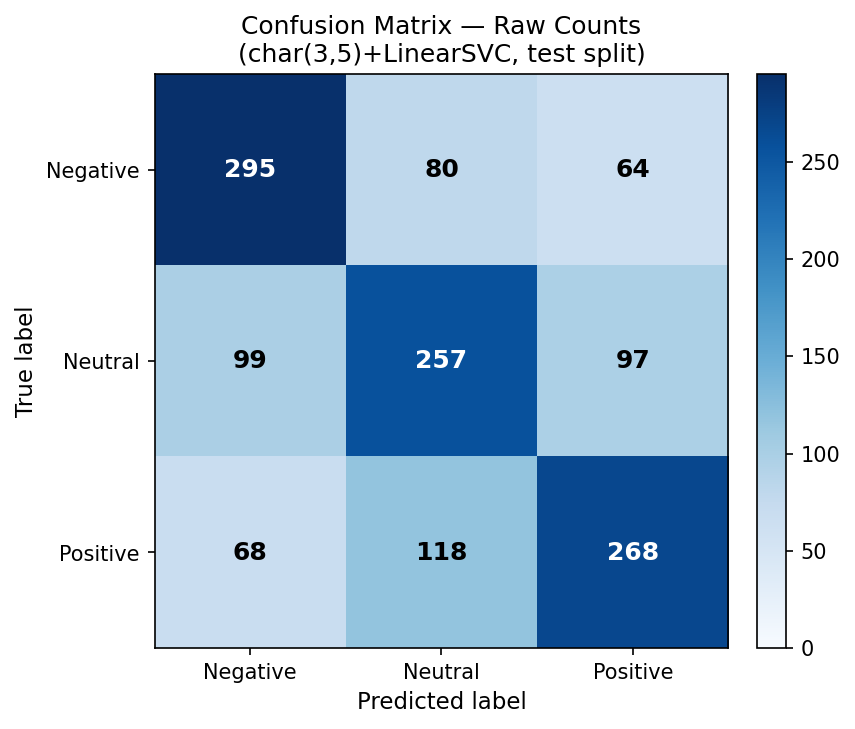

In [14]:
# Confusion matrix figures
print('Raw confusion matrix:')
display(Image(filename=str(fig_dir / 'confusion_matrix.png'), width=420))

Row-normalised confusion matrix:


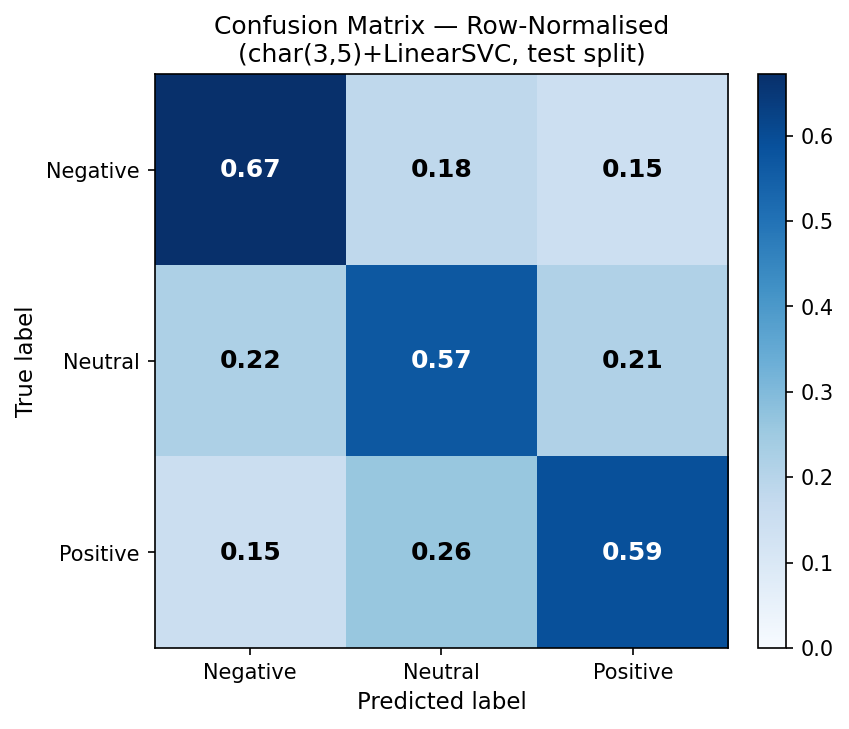

In [15]:
print('Row-normalised confusion matrix:')
display(Image(filename=str(fig_dir / 'confusion_matrix_normalized.png'), width=420))

In [16]:
# Full comparison table (trivial → incumbent → final, all on test)
comparison = pd.DataFrame([
    {'Model': 'Majority-class',          'Test Acc': '32.62%', 'Test macro-F1': '16.40%', 'Note': 'Trivial'},
    {'Model': 'Stratified-random',       'Test Acc': '33.73%', 'Test macro-F1': '33.74%', 'Note': 'Trivial'},
    {'Model': 'char(3,5)+LR C=1.0',      'Test Acc': '60.33%', 'Test macro-F1': '60.35%', 'Note': 'Phase 4 incumbent'},
    {'Model': 'char(3,5)+LinearSVC C=1.0','Test Acc': '60.92%','Test macro-F1': '60.93%', 'Note': 'FINAL (selected)'},
])
comparison.style.set_caption('Model Comparison — All on Test Split').set_properties(**{'text-align': 'left'})

,Model,Test Acc,Test macro-F1,Note
0,Majority-class,32.62%,16.40%,Trivial
1,Stratified-random,33.73%,33.74%,Trivial
2,"char(3,5)+LR C=1.0",60.33%,60.35%,Phase 4 incumbent
3,"char(3,5)+LinearSVC C=1.0",60.92%,60.93%,FINAL (selected)


---
## 7. Error Analysis (Phase 7)

Full report: `reports/error_analysis.md`. Key findings summarised below.

In [17]:
preds_df = pd.read_csv('reports/test_predictions.csv')
errors   = preds_df[preds_df['correct'] == False]

print(f'Total test errors: {len(errors)} / {len(preds_df)} ({len(errors)/len(preds_df)*100:.1f}%)')
print()

print('Error rate per true class:')
for cls in ['Negative', 'Neutral', 'Positive']:
    sub = preds_df[preds_df['true_label'] == cls]
    n_e = (sub['correct'] == False).sum()
    print(f'  {cls:<12}: {n_e}/{len(sub)} = {n_e/len(sub)*100:.1f}%')

print()
print('Confusion pairs:')
pairs = errors.groupby(['true_label','predicted_label']).size().reset_index(name='count').sort_values('count', ascending=False)
print(pairs.to_string(index=False))

Total test errors: 526 / 1346 (39.1%)

Error rate per true class:
  Negative    : 144/439 = 32.8%
  Neutral     : 196/453 = 43.3%
  Positive    : 186/454 = 41.0%

Confusion pairs:
true_label predicted_label  count
  Positive         Neutral    118
   Neutral        Negative     99
   Neutral        Positive     97
  Negative         Neutral     80
  Positive        Negative     68
  Negative        Positive     64


Error counts by confusion pair:


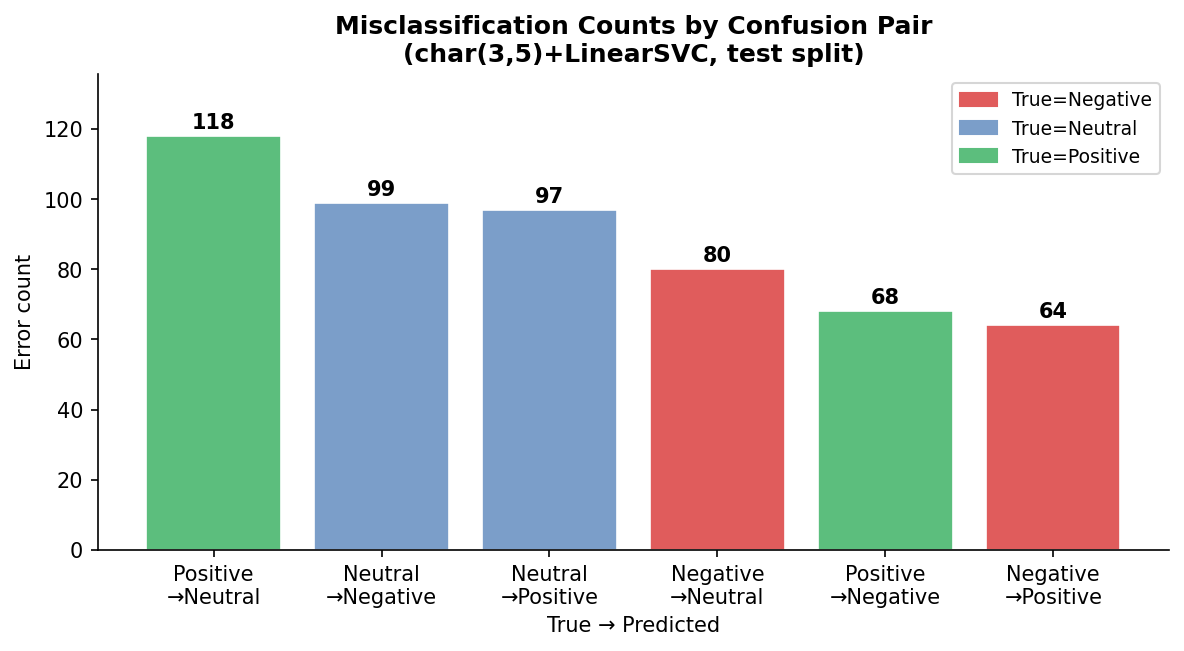

In [18]:
print('Error counts by confusion pair:')
display(Image(filename=str(fig_dir / 'error_by_pair.png'), width=620))

In [19]:
# Named failure categories (from reviewed_errors.csv)
rev_df = pd.read_csv('reports/reviewed_errors.csv')
cat_summary = rev_df['failure_category'].value_counts().reset_index()
cat_summary.columns = ['Category', 'Count']
cat_summary['% of reviewed'] = (cat_summary['Count'] / len(rev_df) * 100).round(1).astype(str) + '%'
print(f'Named failure categories ({len(rev_df)} reviewed errors):')
cat_summary.style.set_caption('Phase 7 — Failure Categories (20 reviewed errors)').hide(axis='index')

Named failure categories (20 reviewed errors):


Category,Count,% of reviewed
NEGATION,4,20.0%
MIXED_SENTIMENT,4,20.0%
FACTUAL_CONTEXT,4,20.0%
SARCASM_IRONY,3,15.0%
AMBIGUOUS_LABEL,3,15.0%
MILD_POSITIVE,2,10.0%


In [20]:
# Sample reviewed errors
rev_df[['text_id','true_label','predicted_label','failure_category','note']].head(10) \
    .style.set_caption('Sample Reviewed Errors (10 of 20)').hide(axis='index')

text_id,true_label,predicted_label,failure_category,note
TXT_00087,Negative,Positive,NEGATION,"""not excited"" — negation scope missed; 'excited' char-grams dominate"
TXT_00093,Positive,Negative,NEGATION,"""won't be just a Party"" — double negation reads as negative; actual meaning is enthusiastic"
TXT_00224,Positive,Negative,NEGATION,"Duplicate of TXT_00093 — same text, same confusion, confirms systematic negation blind spot"
TXT_00225,Neutral,Negative,NEGATION,"""do not live in...victim mentality"" — negation-heavy phrasing triggers negative features despite neutral/motivational tone"
TXT_00064,Negative,Positive,MIXED_SENTIMENT,Praises Wilkie ('man of principle') but criticises Garrett — model latches on to positive praise half
TXT_00128,Positive,Neutral,MIXED_SENTIMENT,Acknowledges past shortfall ('left us short') then expresses optimism ('Kane saved') — mixed signals
TXT_00185,Positive,Neutral,MIXED_SENTIMENT,"Cautious optimism with hedging language ('may', 'under pressure') — genuine borderline case"
TXT_00698,Positive,Negative,MIXED_SENTIMENT,Political sarcasm praising Clinton — positive intent wrapped in attacking language about Citizens United
TXT_00181,Neutral,Negative,FACTUAL_CONTEXT,"""committed manslaughter"" is factual-news report; crime vocabulary triggers Negative"
TXT_00379,Negative,Neutral,FACTUAL_CONTEXT,Political complaint about scheduling — nuanced critique reads as factual statement


---
## 8. Inference Pipeline Demo (Phase 8)

Demonstrates the production inference pipeline. Uses the same `clean_text()` from `src/utils.py` that was used at training time.

In [21]:
import importlib
inference_pipeline = importlib.import_module("08_inference_pipeline")
load_model = inference_pipeline.load_model
predict = inference_pipeline.predict

bundle = load_model()
print(f'Model loaded: {bundle["config"]["config_description"]}')
print(f'Trained on  : {bundle["config"]["trained_on"]}')

Model loaded: char(3,5)+LinearSVC C=1.0
Trained on  : train+val combined (7654 rows)


In [22]:
demo_texts = [
    "This is absolutely amazing! I love every single moment of it :)",
    "Worst day ever. I hate this so much. :(",
    "The event is scheduled for Saturday at 3:30 PM at the downtown venue.",
    "I'm not at all excited about this, not even a little.",
    r"Tune into @DhritTV tonight\u2019s finale! It\u2019s &amp; always a blast. https://example.com",
]

results = predict(demo_texts, bundle)
for r in results:
    print(f'  [{r["label"]:<10}] {r["raw_text"][:80]}')

  [Positive  ] This is absolutely amazing! I love every single moment of it :)
  [Negative  ] Worst day ever. I hate this so much. :(
  [Neutral   ] The event is scheduled for Saturday at 3:30 PM at the downtown venue.
  [Negative  ] I'm not at all excited about this, not even a little.
  [Neutral   ] Tune into @DhritTV tonight\u2019s finale! It\u2019s &amp; always a blast. https:


In [23]:
# Verify cleaning runs at inference time
raw_issues = r"Tune into @DhritTV for tonight\u2019s show! It\u2019s &amp; great."
r = predict([raw_issues], bundle)[0]
print(f'Raw   : {raw_issues}')
print(f'Clean : {r["clean_text"]}')
print(f'Label : {r["label"]}')
assert r'\u2019' not in r['clean_text'],  'FAIL: unicode not decoded'
assert '&amp;'   not in r['clean_text'],  'FAIL: HTML not decoded'
assert '@DhritTV' not in r['clean_text'], 'FAIL: mention not normalised'
assert '@user'   in r['clean_text'],      'FAIL: @user not present'
print('All cleaning assertions passed.')

Raw   : Tune into @DhritTV for tonight\u2019s show! It\u2019s &amp; great.
Clean : Tune into @user for tonight’s show! It’s & great.
Label : Positive
All cleaning assertions passed.


---
## 9. Summary

| Phase | Key Output | Status |
|---|---|---|
| 1 — Data Audit | 9,000 rows, 3 balanced classes, text-quality issues quantified | ✅ |
| 2 — Preprocessing | Group-aware leakage-safe split; 4 cleaning steps; 0 leakage | ✅ |
| 3 — EDA | 6 figures; vocab size, class-conditional lexicons | ✅ |
| 4 — Baselines | char(3,5)+LR incumbent val macro-F1=58.81% | ✅ |
| 5 — Experiments | 5-exp fast path; Exp-D (LinearSVC) wins at val F1=60.11% | ✅ |
| 6 — Evaluation | Test macro-F1=**60.93%**; val/test gap=+0.82 pp | ✅ |
| 7 — Error Analysis | 6 failure categories; negation (+8 pp error rate) is key finding | ✅ |
| 8 — Inference | Fresh-process verification passed; all cleaning checks passed | ✅ |

**Final model**: `char(3,5)+LinearSVC C=1.0`, retrained on train+val (7,654 rows).  
**Test macro-F1 = 60.93%** (+44.53 pp over majority-class trivial baseline, +0.58 pp over Phase 4 incumbent on test).